# MLP — Telco Customer Churn

Dataset: IBM Telco Customer Churn (~7.000 registros, ~30 features pós feature-engineering, target `Churn`)

**Fluxo:**
1. Setup (seeds, config, device)
2. Carregar dados (loader + feature pipeline)
3. Split estratificado + conversão para tensores
4. Definir modelo (ChurnMLP)
5. Loop de treinamento com early stopping
6. Avaliar no test set (accuracy, ROC AUC, recall, precision, F1)
7. Curvas ROC e PR + threshold ótimo
8. Matriz de confusão
9. Persistir modelo e registrar no MLflow

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.data.loader import load_raw
from src.features.pipeline import build_pipeline, fit_transform, transform

RANDOM_SEED = 42
TARGET = "Churn"
TEST_SIZE = 0.2

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

cfg = load_config()
print(f"Config: {cfg['training']}")
print(f"Model:  {cfg['model']}")

Device: cpu
Config: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100, 'weight_decay': 0.0001, 'early_stopping_patience': 10, 'scheduler_patience': 5}
Model:  {'hidden_dims': [64, 32], 'dropout': [0.3, 0.2]}


## 2. Carregar dados e feature pipeline

In [4]:
df, dataset_hash = load_raw(str(PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print(f"Shape: {df.shape} | Hash: {dataset_hash}")

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y,
)

pipeline = build_pipeline()
X_train = fit_transform(pipeline, X_train_raw)
X_test = transform(pipeline, X_test_raw)

n_features = X_train.shape[1]
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Features: {n_features} | pos_weight: {pos_weight:.4f}")
print(f"Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}")

2026-04-22 22:55:10 [info     ] data.loaded                    path=c:\Users\Microsoft\Desktop\FIAP\Tech-Challenge01\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv shape=(7043, 21)
2026-04-22 22:55:10 [info     ] data.total_charges_fixed       blanks=11 imputed_with=1397.47


2026-04-22 22:55:10 [info     ] data.ready                     hash=58235c7e5c2ce5014bc3ed883fa08c1f shape=(7043, 20)
Shape: (7043, 20) | Hash: 58235c7e5c2ce5014bc3ed883fa08c1f
2026-04-22 22:55:10 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(5634, 15)
2026-04-22 22:55:10 [info     ] pipeline.fit_transform         output_shape=(5634, 30)
2026-04-22 22:55:10 [info     ] features.engineered            dropped=['gender', 'PhoneService', 'MultipleLines', 'TotalCharges', 'StreamingTV', 'StreamingMovies'] new_cols=['log_tenure', 'is_fiber', 'n_add_on_services'] shape=(1409, 15)
Features: 30 | pos_weight: 2.7686
Treino: 5634 | Teste: 1409


## 3. Converter para tensores e DataLoaders

In [5]:
batch_size = cfg["training"]["batch_size"]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

print(f"Batch size: {batch_size} | Batches por época: {len(train_loader)}")

Batch size: 32 | Batches por época: 177


## 4. Definir modelo

In [6]:
class ChurnMLP(nn.Module):
    def __init__(self, input_dim: int, hidden: list[int] = [64, 32],
                 dropout: list[float] = [0.3, 0.2]) -> None:
        super().__init__()
        layers = []
        in_dim = input_dim
        for h, d in zip(hidden, dropout):
            layers.extend([
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(d),
            ])
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

model = ChurnMLP(
    input_dim=n_features,
    hidden=cfg["model"]["hidden_dims"],
    dropout=cfg["model"]["dropout"],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parâmetros: {total_params:,}")
print(model)

Parâmetros: 4,289
ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Treinamento com early stopping

In [8]:
lr = cfg["training"]["learning_rate"]
weight_decay = cfg["training"]["weight_decay"]
epochs = cfg["training"]["epochs"]
es_patience = cfg["training"]["early_stopping_patience"]
sched_patience = cfg["training"]["scheduler_patience"]

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=sched_patience)

best_val_loss = float("inf")
patience_counter = 0
best_state = None
history = {"train_loss": [], "val_loss": [], "val_roc_auc": []}

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_test_t.to(device))
        val_loss = criterion(val_logits, y_test_t.to(device)).item()
        val_probs = torch.sigmoid(val_logits).cpu().numpy().ravel()
        val_roc = roc_auc_score(y_test.values, val_probs)

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_roc_auc"].append(val_roc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model.state_dict().copy()
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_roc={val_roc:.4f} lr={current_lr:.1e}")

    if patience_counter >= es_patience:
        print(f"\nEarly stopping na época {epoch} (patience={es_patience})")
        break

model.load_state_dict(best_state)
print(f"\nMelhor val_loss: {best_val_loss:.4f}")

Epoch   1 | train_loss=0.8017 val_loss=0.7173 val_roc=0.8433 lr=1.0e-03
Epoch  10 | train_loss=0.7239 val_loss=0.7177 val_roc=0.8425 lr=1.0e-03

Early stopping na época 15 (patience=10)

Melhor val_loss: 0.7099


## 6. Curvas de treino

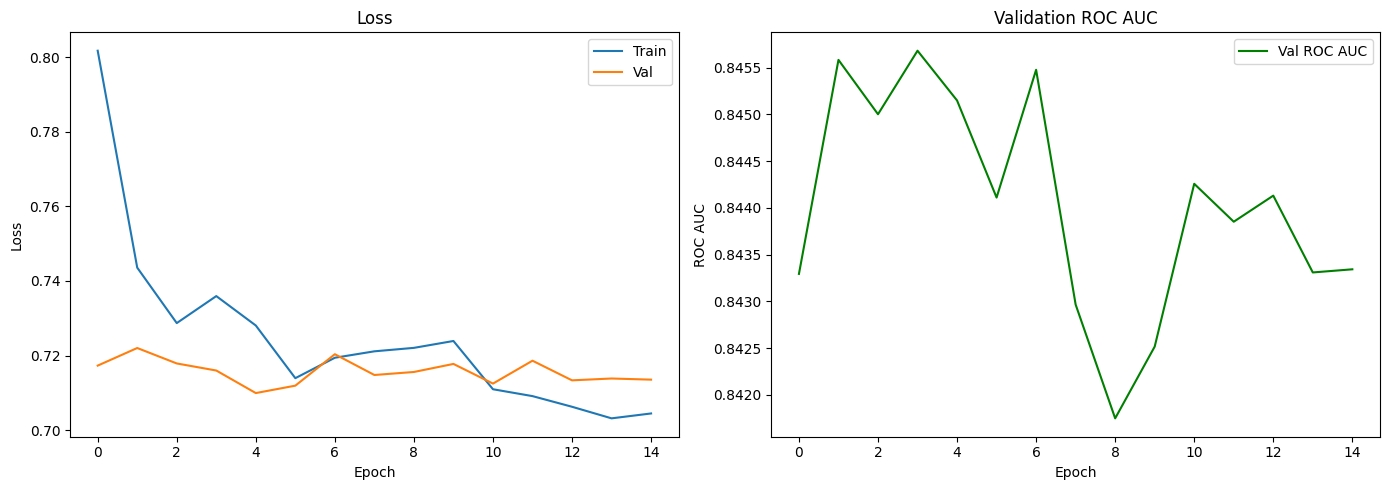

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(history["val_roc_auc"], label="Val ROC AUC", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("ROC AUC")
ax2.set_title("Validation ROC AUC")
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Avaliar no test set

In [10]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t.to(device))
    test_probs = torch.sigmoid(test_logits).cpu().numpy().ravel()

y_pred = (test_probs >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, test_probs)
pr_auc = average_precision_score(y_test, test_probs)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"ROC AUC:   {roc:.4f}")
print(f"PR AUC:    {pr_auc:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1:        {f1:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])}")

Accuracy:  0.7530
ROC AUC:   0.8433
PR AUC:    0.6611
Recall:    0.7941
Precision: 0.5229
F1:        0.6306

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



## 8. Curvas ROC e PR + threshold ótimo

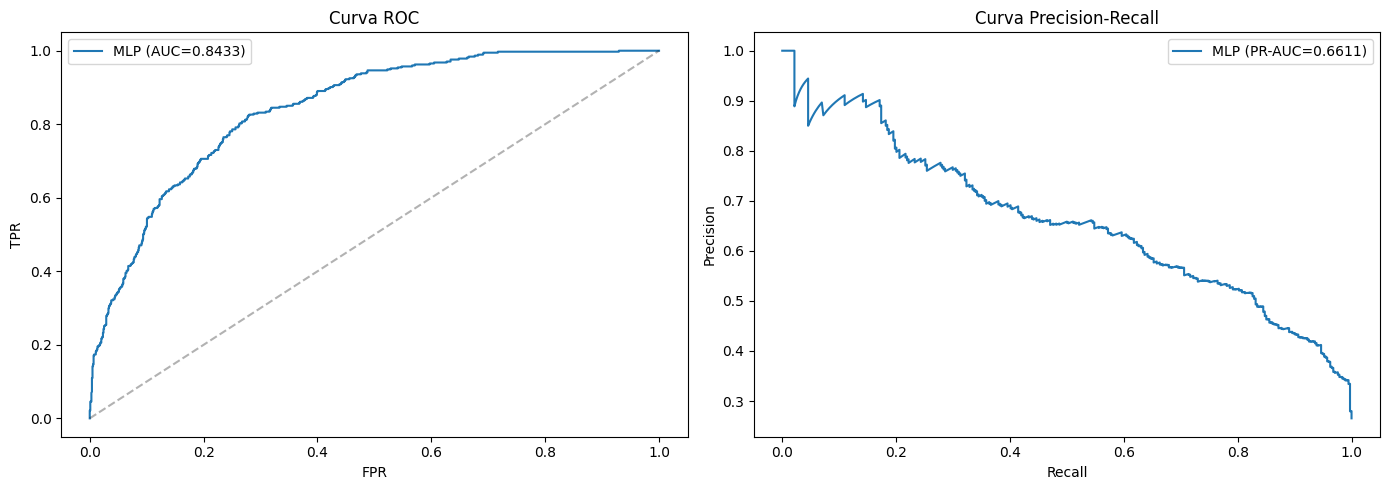

Threshold ótimo (Expected Profit): 0.08
Expected Profit no test set: R$ 378,120


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, test_probs)
ax1.plot(fpr, tpr, label=f"MLP (AUC={roc:.4f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax1.set_xlabel("FPR")
ax1.set_ylabel("TPR")
ax1.set_title("Curva ROC")
ax1.legend()

prec_curve, rec_curve, thresholds = precision_recall_curve(y_test, test_probs)
ax2.plot(rec_curve, prec_curve, label=f"MLP (PR-AUC={pr_auc:.4f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Curva Precision-Recall")
ax2.legend()

plt.tight_layout()
plt.show()

# Threshold ótimo via Expected Profit: TP*1140 - FP*60 - FN*1200
best_profit = -float("inf")
best_threshold = 0.5
for t in np.arange(0.05, 0.95, 0.01):
    preds = (test_probs >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm_t.ravel()
    profit = tp * 1140 - fp * 60 - fn * 1200
    if profit > best_profit:
        best_profit = profit
        best_threshold = t

print(f"Threshold ótimo (Expected Profit): {best_threshold:.2f}")
print(f"Expected Profit no test set: R$ {best_profit:,.0f}")

## 9. Matriz de confusão

Métricas com threshold otimizado (0.08):
  Recall:    0.9973
  Precision: 0.3278
  F1:        0.4934


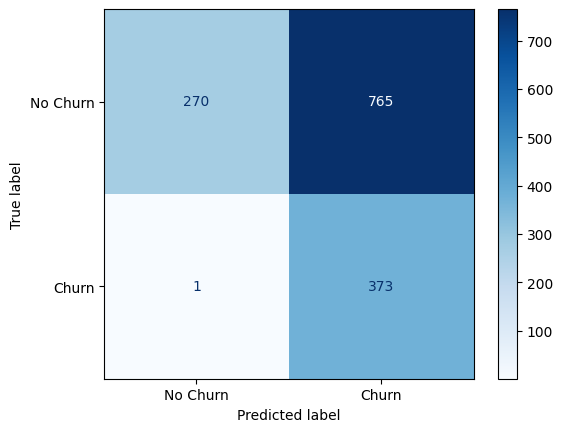

In [13]:
y_pred_opt = (test_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(cmap="Blues")
print(f"Métricas com threshold otimizado ({best_threshold:.2f}):")
print(f"  Recall:    {recall_score(y_test, y_pred_opt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_opt):.4f}")

## 10. Persistir modelo e registrar no MLflow

In [11]:
model_path = PROJECT_ROOT / "models" / "mlp_best.pt"
torch.save(model.state_dict(), model_path)
print(f"Modelo salvo em: {model_path}")

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}")
mlflow.set_experiment("churn-mlp")

metrics_dict = {
    "accuracy": acc,
    "roc_auc": roc,
    "pr_auc": pr_auc,
    "recall": rec,
    "precision": prec,
    "f1": f1,
    "best_threshold": best_threshold,
    "expected_profit": float(best_profit),
}

with mlflow.start_run(run_name="mlp_baseline"):
    mlflow.log_params({
        "input_dim": n_features,
        "hidden_dims": str(cfg["model"]["hidden_dims"]),
        "dropout": str(cfg["model"]["dropout"]),
        "learning_rate": lr,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "epochs_trained": len(history["train_loss"]),
        "epochs_max": epochs,
        "early_stopping_patience": es_patience,
        "random_seed": RANDOM_SEED,
        "test_size": TEST_SIZE,
    })
    mlflow.log_metrics(metrics_dict)
    mlflow.log_artifact(str(model_path))
    mlflow.set_tag("dataset_hash", dataset_hash)
    run_id = mlflow.active_run().info.run_id

print(f"Run MLflow registrado: {run_id}")
print(f"Métricas: {metrics_dict}")

Modelo salvo em: c:\Users\Microsoft\Desktop\FIAP\Tech-Challenge01\models\mlp_best.pt


2026/04/22 23:01:21 INFO mlflow.tracking.fluent: Experiment with name 'churn-mlp' does not exist. Creating a new experiment.


NameError: name 'best_threshold' is not defined